<a href="https://colab.research.google.com/github/sanchi23002/COMPUTER_VISION_WITH_OPENCV_AND_DEEP_LEARNING/blob/main/corner_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import cv2
import numpy as np

import matplotlib.pyplot as plt

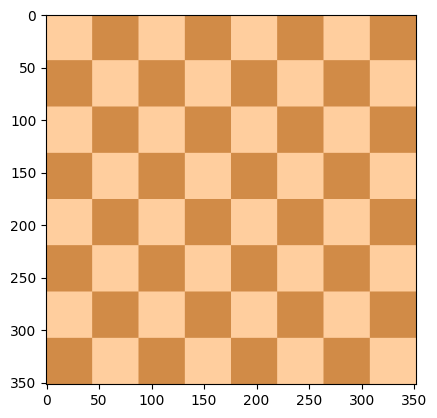

In [2]:
flat_chess = cv2.imread('flat_chessboard.png')
flat_chess = cv2.cvtColor(flat_chess,cv2.COLOR_BGR2RGB)
plt.imshow(flat_chess)

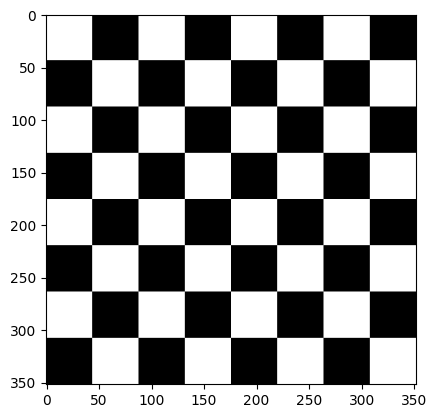

In [3]:
gray_flat_chess = cv2.cvtColor(flat_chess,cv2.COLOR_BGR2GRAY)
plt.imshow(gray_flat_chess,cmap='gray')

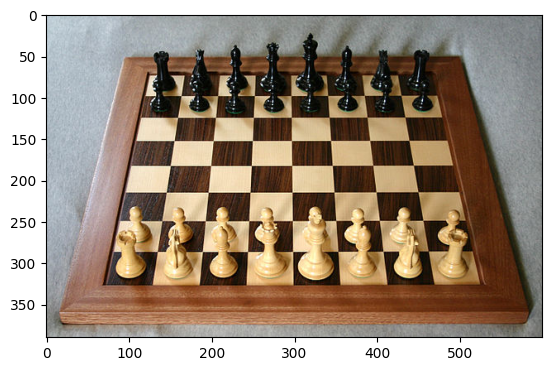

In [4]:
real_chess = cv2.imread('real_chessboard.jpg')
real_chess = cv2.cvtColor(real_chess,cv2.COLOR_BGR2RGB)
plt.imshow(real_chess)

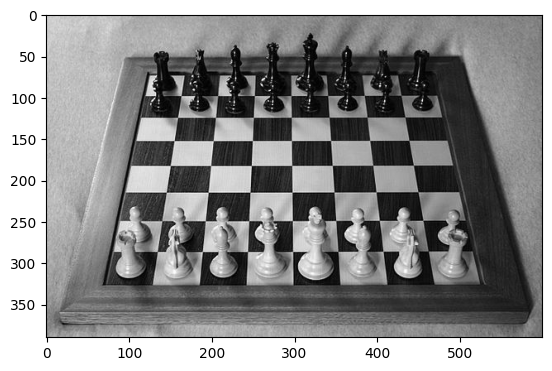

In [5]:
gray_real_chess = cv2.cvtColor(real_chess,cv2.COLOR_BGR2GRAY)
plt.imshow(gray_real_chess,cmap='gray')

# Harris Corner Detection

**cornerHarris Function**

*  src Input single-channel 8-bit or floating-point image.
*  dst Image to store the Harris detector responses. It has the type CV_32FC1 and the same size as src .
*  blockSize Neighborhood size (see the details on #cornerEigenValsAndVecs ).
*  ksize Aperture parameter for the Sobel operator.
*  k Harris detector free parameter. See the formula in DocString
*  borderType Pixel extrapolation method. See #BorderTypes.

1. What is an Edge? (The Core Concept)
In a digital image, an edge occurs where there is a sudden, sharp change in pixel brightness (intensity).

Imagine a picture of a white square on a black background.

As you scan across the image horizontally, the pixel values suddenly jump from 0 (pure black) to 255 (pure white).

That sudden jump is a gradient. The Sobel operator is designed to calculate the size and direction of these brightness gradients.

✅The Horizontal Kernel ($G_x$)This filter detects vertical edges by measuring changes moving horizontally (left-to-right):$$G_x = \begin{bmatrix} -1 & 0 & +1 \\ -2 & 0 & +2 \\ -1 & 0 & +1 \end{bmatrix}$$

✅The Vertical Kernel ($G_y$)This filter detects horizontal edges by measuring changes moving vertically (top-to-bottom):$$G_y = \begin{bmatrix} -1 & -2 & -1 \\  0 &  0 &  0 \\ +1 & +2 & +1 \end{bmatrix}$$

# Technically valid syntax
sobel_both = cv2.Sobel(img, cv2.CV_64F, 1, 1, ksize=3)

However, you should almost never do this if your goal is standard edge detection.

$$\text{Kernel for (1,1)} = \begin{bmatrix} -1 & 0 & +1 \\  0 & 0 &  0 \\ +1 & 0 & -1 \end{bmatrix}$$ , it is not good for both

✅gray = np.float32(gray_flat_chess): The Harris Corner Detector function cv2.cornerHarris expects the input image to be of floating-point type, so this line converts the grayscale image from its original data type (likely uint8) to float32.


dst = cv2.cornerHarris(src=gray, blockSize=2, ksize=3, k=0.04): This is the core Harris Corner Detection step. It calculates a 'corner response' map.
src=gray: The input grayscale image.


blockSize=2: The size of the neighborhood considered for corner detection.
ksize=3: The aperture parameter for the Sobel operator used internally.
k=0.04: The Harris detector free parameter, often set between 0.04 and 0.06.
dst = cv2.dilate(dst, None): The dst (destination) image now contains raw corner responses. This line dilates the dst image. Dilation is a morphological operation that expands bright areas. In this context, it helps to make the detected corner points larger and more visible, making them easier to mark and visualize on the original image.


flat_chess[dst > 0.01 * dst.max()] = [255, 0, 0]: This line identifies and marks the corners on the original color flat_chess image.
dst.max(): Finds the maximum corner response value in the dst image.
0.01 * dst.max(): Sets a threshold. Any pixel in dst with a corner response greater than 1% of the maximum response is considered a corner.


flat_chess[...] = [255, 0, 0]: For all pixels identified as corners, their corresponding pixels in the flat_chess image are set to [255, 0, 0], which is bright red, effectively drawing the detected corners.

1. blockSize (Most Important for Feature Scale)


Priority: This is often the first parameter to consider because it defines the scale at which you are looking for corners. It dictates the size of the neighborhood used to calculate the gradients and the Structure Tensor. This implicitly determines how 'large' a corner feature the algorithm will be sensitive to.


How to tune: Start with a small value (e.g., 2 or 3) to detect fine corners. If you're detecting too many small, insignificant features or noise, increase blockSize to focus on larger, more prominent corners.


2. ksize (For Gradient Smoothness/Noise Sensitivity)


Priority: After setting the general scale with blockSize, ksize comes next as it influences the quality of the gradient calculations within that neighborhood. It affects the sensitivity to noise and the precision of gradient estimations.


How to tune: A ksize of 3 is a good default. If your image is noisy, increasing it (e.g., to 5 or 7) can smooth out gradients, making the detector more robust. If your image is very clean and you need precise localization of corners, ksize=3 is usually sufficient.


3. k (For Corner-Edge Discrimination)


Priority: This is usually the final parameter to fine-tune. k is the empirical constant that balances the determinant and trace of the Structure Tensor in the Harris response function. It helps discriminate between true corners and edge-like structures.


How to tune: The typical range for k is 0.04 to 0.06. Start with a value in the middle (e.g., 0.04 or 0.05). If you find the detector is picking up too many edge points as corners, slightly increase k. If it's missing valid corners, slightly decrease k.


In summary, the recommended tuning hierarchy is: blockSize -> ksize -> k



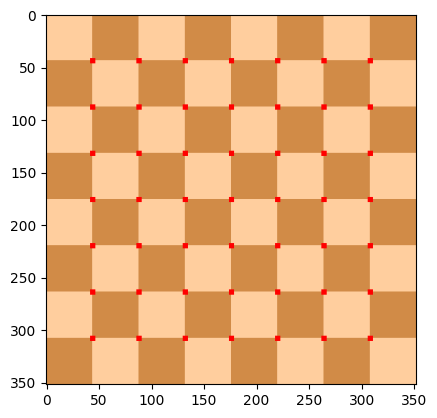

In [6]:
# Convert Gray Scale Image to Float Values
gray = np.float32(gray_flat_chess)

# Corner Harris Detection
dst = cv2.cornerHarris(src=gray,blockSize=2,ksize=3,k=0.04)

# result is dilated for marking the corners, not important to actual corner detection
# this is just so we can plot out the points on the image shown
dst = cv2.dilate(dst,None)

# Threshold for an optimal value, it may vary depending on the image.
flat_chess[dst>0.01*dst.max()]=[255,0,0]

plt.imshow(flat_chess)

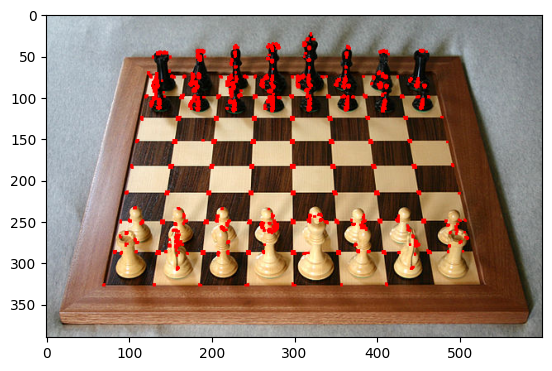

In [10]:
# Convert Gray Scale Image to Float Values
gray = np.float32(gray_real_chess)

# Corner Harris Detection
dst = cv2.cornerHarris(src=gray,blockSize=2,ksize=5,k=0.06)

# result is dilated for marking the corners, not important to actual corner detection
# this is just so we can plot out the points on the image shown
dst = cv2.dilate(dst,None)

# Threshold for an optimal value, it may vary depending on the image.
real_chess[dst>0.01*dst.max()]=[255,0,0]

plt.imshow(real_chess)

-----

## Shi-Tomasi Corner Detector & Good Features to Track Paper

[Link to Paper from Video](http://www.ai.mit.edu/courses/6.891/handouts/shi94good.pdf)

goodFeatureToTrack Function Parameters

* image Input 8-bit or floating-point 32-bit, single-channel image.
* corners Output vector of detected corners.
* maxCorners Maximum number of corners to return. If there are more corners than are found,the strongest of them is returned. `maxCorners <= 0` implies that no limit on the maximum is set and all detected corners are returned.
* qualityLevel Parameter characterizing the minimal accepted quality of image corners. The parameter value is multiplied by the best corner quality measure, which is the minimal eigenvalue (see #cornerMinEigenVal ) or the Harris function response (see #cornerHarris ). The corners with the quality measure less than the product are rejected. For example, if the best corner has the quality measure = 1500, and the qualityLevel=0.01 , then all the corners with the quality measure less than 15 are rejected.

In [14]:
# Need to reset the images since we drew on them
flat_chess = cv2.imread('flat_chessboard.png')
flat_chess = cv2.cvtColor(flat_chess,cv2.COLOR_BGR2RGB)
gray_flat_chess = cv2.cvtColor(flat_chess,cv2.COLOR_BGR2GRAY)

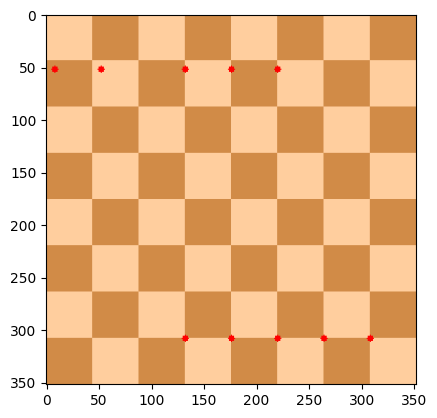

In [17]:
corners = cv2.goodFeaturesToTrack(gray_flat_chess,5,0.01,10)
corners = np.intp(corners)

for i in corners:
    x,y = i.ravel()
    cv2.circle(flat_chess,(x,y),3,255,-1)

plt.imshow(flat_chess)

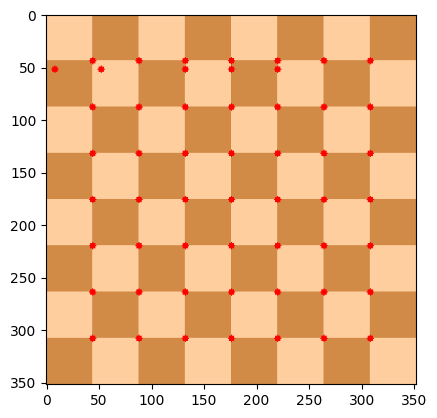

In [18]:
corners = cv2.goodFeaturesToTrack(gray_flat_chess,64,0.01,10)
corners = np.intp(corners)

for i in corners:
    x,y = i.ravel()
    cv2.circle(flat_chess,(x,y),3,255,-1)

plt.imshow(flat_chess)

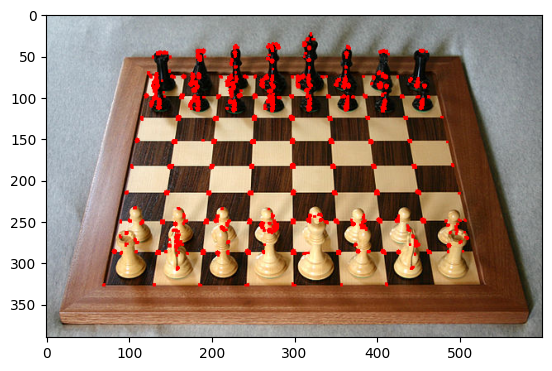

In [19]:
corners = cv2.goodFeaturesToTrack(gray_real_chess,80,0.01,10)
corners = np.intp(corners)

for i in corners:
    x,y = i.ravel()
    cv2.circle(real_chess,(x,y),3,255,-1)

plt.imshow(real_chess)